Plots werden in folgender Reihenfolge erzeugt:
   Messung 1.dat
   Messung 2.dat
   Messung 3,1.dat
   Teil2_Messung 1.dat
   Teil 2_Messung 2.dat
   Teil 2_Messung 3.dat

Verarbeite: Messung 1.dat


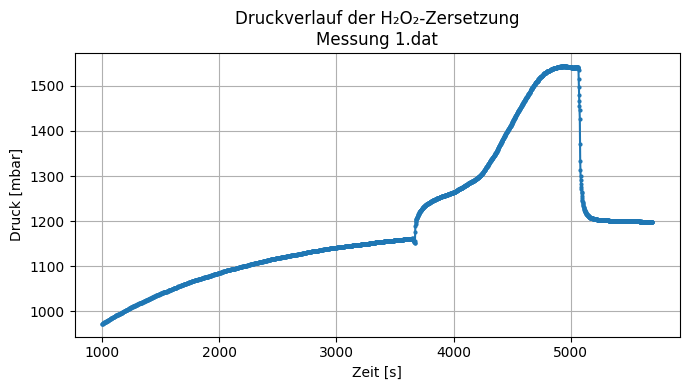


Verarbeite: Messung 2.dat


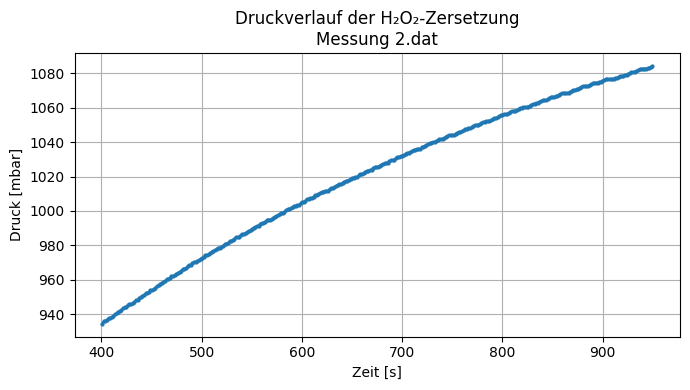


Verarbeite: Messung 3,1.dat


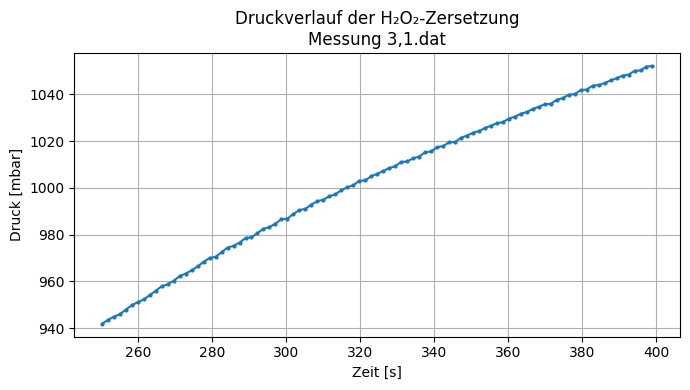


Verarbeite: Teil2_Messung 1.dat


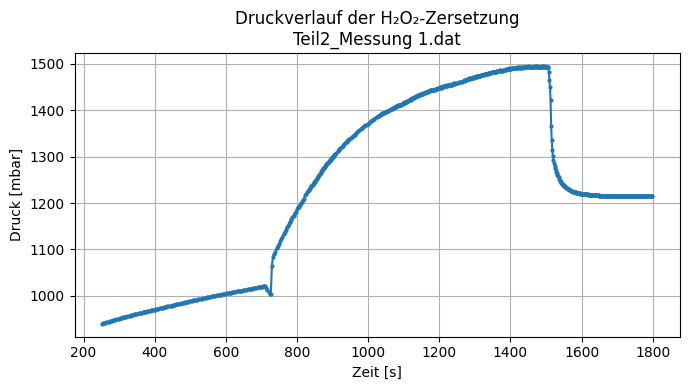


Verarbeite: Teil 2_Messung 2.dat


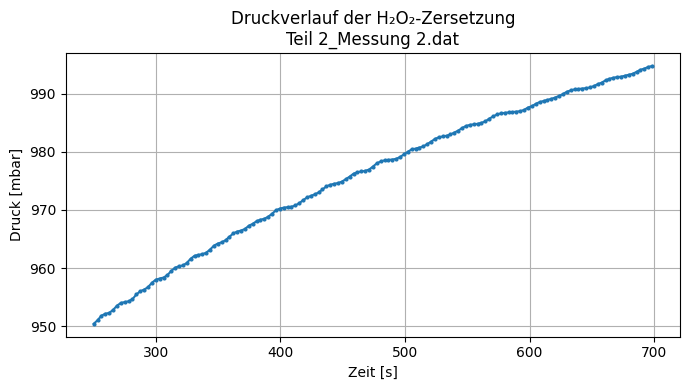


Verarbeite: Teil 2_Messung 3.dat


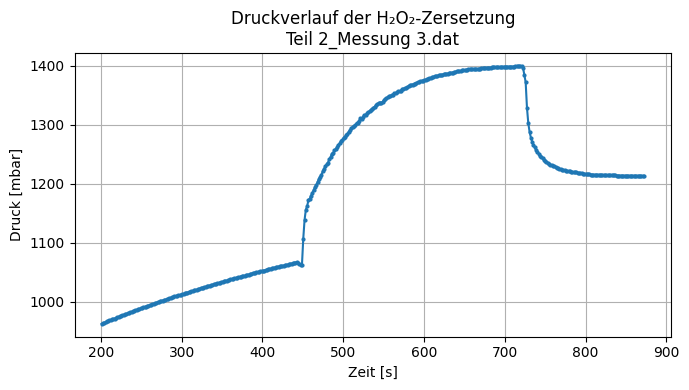

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1️⃣ Ordner mit Messdateien
# ================================
eingabe_ordner = (
    "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/"
    "PR Physikalische Chemie II/Experiment_3_H2O2/Messungen"
)

# ================================
# 2️⃣ Wunsch-Reihenfolge der Plots
# ================================
reihenfolge = [
    "Messung 1.dat",
    "Messung 2.dat",
    "Messung 3,1.dat",
    "Teil2_Messung 1.dat",
    "Teil 2_Messung 2.dat",
    "Teil 2_Messung 3.dat",
]

# ================================
# 3️⃣ Zeitfenster pro Datei
# ================================
zeitfenster = {
    "Messung 1.dat": (1000, 6000),
    "Messung 2.dat": (400, 950),
    "Messung 3,1.dat": (250, 400),
    "Teil2_Messung 1.dat": (250, 1800),
    "Teil 2_Messung 2.dat": (250, 700),
    "Teil 2_Messung 3.dat": (200, 1000),
}

# ================================
# 4️⃣ Pfade in Wunschreihenfolge erzeugen
# ================================
pfade = [os.path.join(eingabe_ordner, name) for name in reihenfolge]

print("Plots werden in folgender Reihenfolge erzeugt:")
for name in reihenfolge:
    print("  ", name)

# ================================
# 5️⃣ Dateien verarbeiten
# ================================
for pfad in pfade:
    name = os.path.basename(pfad)
    print("\nVerarbeite:", name)

    if not os.path.exists(pfad):
        print(f"⚠️ Datei nicht gefunden: {name}")
        continue

    df = pd.read_csv(
        pfad,
        sep=r"\s+",
        decimal=",",
        header=None,
        names=["Zeit", "Druck"],
        engine="python"
    )

    df = df.dropna()

    if name in zeitfenster:
        t_min, t_max = zeitfenster[name]
        df = df[(df["Zeit"] >= t_min) & (df["Zeit"] <= t_max)]

        if df.empty:
            print(f"⚠️ Kein gültiger Datenbereich für {name}")
            continue

    plt.figure(figsize=(7,4))
    plt.plot(df["Zeit"], df["Druck"], marker="o", linestyle="-", markersize=2)

    plt.xlabel("Zeit [s]")
    plt.ylabel("Druck [mbar]")
    plt.title(f"Druckverlauf der H₂O₂-Zersetzung\n{name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Gefundene Dateien (sortiert):
   Messung 1.dat
   Messung 2.dat
   Messung 3,1.dat
   Messung 3.dat
   Messung_2.dat
   Teil 2_Messung 2.dat
   Teil 2_Messung 3.dat
   Teil2_Messung 1.dat
   ~$O2_No2_09Dez2025_153136.dat
   ~$ssung_2.dat

Verarbeite: Messung 1.dat


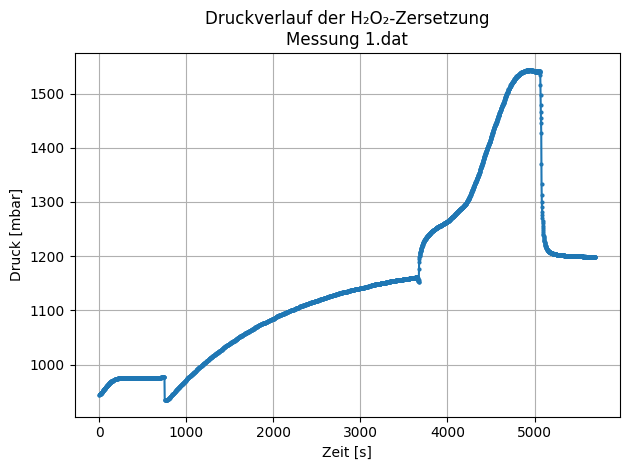


Verarbeite: Messung 2.dat


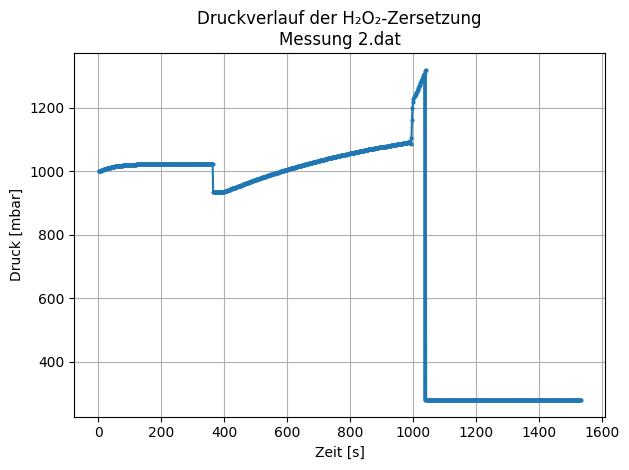


Verarbeite: Messung 3,1.dat


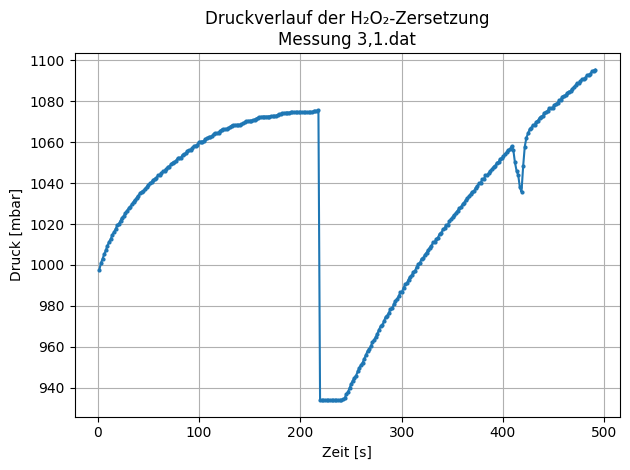


Verarbeite: Messung 3.dat


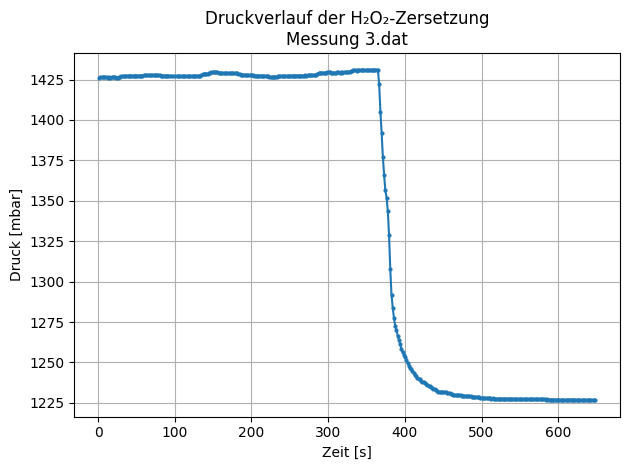


Verarbeite: Messung_2.dat


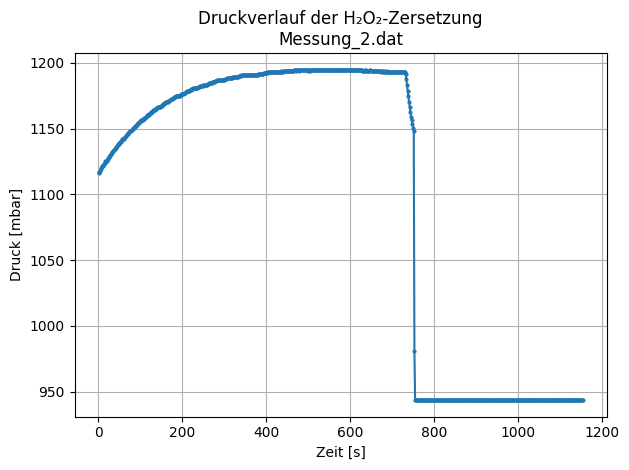


Verarbeite: Teil 2_Messung 2.dat


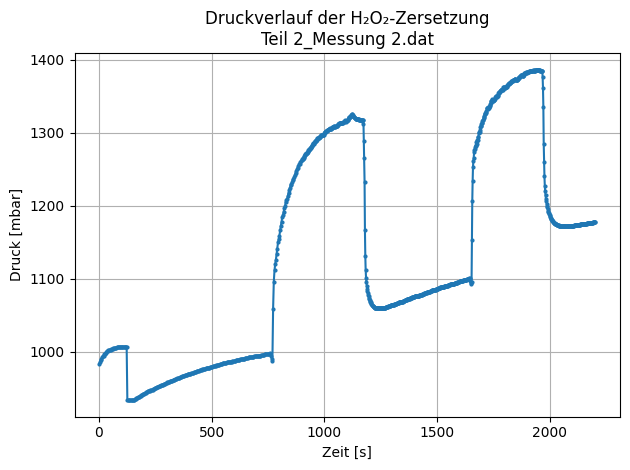


Verarbeite: Teil 2_Messung 3.dat


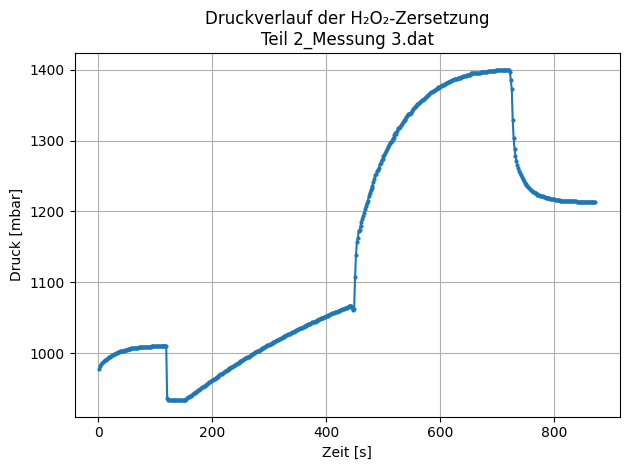


Verarbeite: Teil2_Messung 1.dat


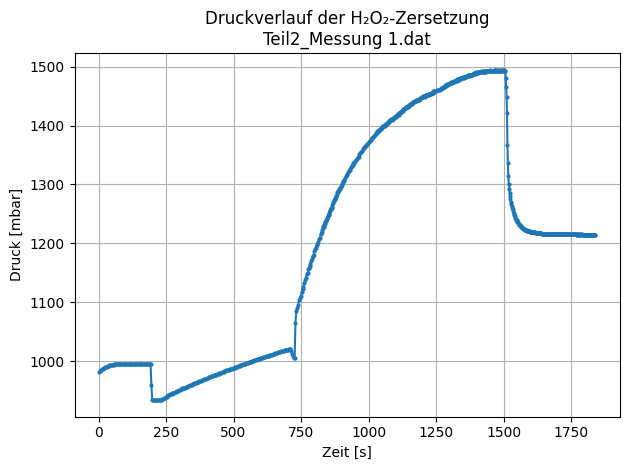


Verarbeite: ~$O2_No2_09Dez2025_153136.dat


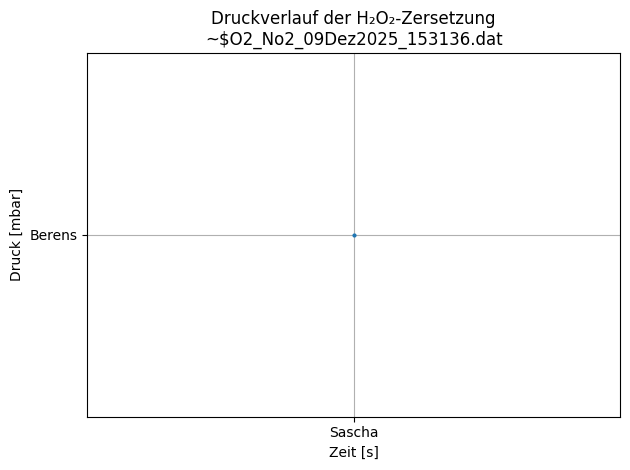


Verarbeite: ~$ssung_2.dat


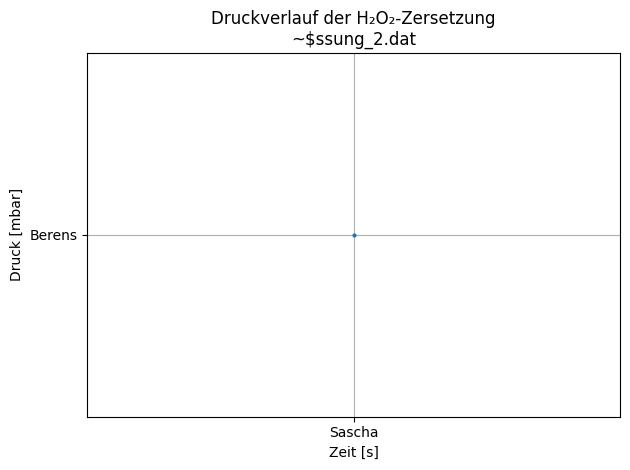

In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

eingabe_ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Physikalische Chemie II/Experiment_3_H2O2/Messungen"

pfade = glob.glob(os.path.join(eingabe_ordner, "*.dat"))
pfade.sort()   # <<< WICHTIG: sortiert die Dateien der Reihe nach!

print("Gefundene Dateien (sortiert):")
for p in pfade:
    print("  ", os.path.basename(p))

for pfad in pfade:
    print("\nVerarbeite:", os.path.basename(pfad))

    df = pd.read_csv(pfad, sep=r"\s+", decimal=",", header=None)
    df.columns = ["Zeit", "Druck"]
    df = df.dropna()

    plt.figure()
    plt.plot(df["Zeit"], df["Druck"], marker="o", linestyle="-", markersize=2)
    plt.xlabel("Zeit [s]")
    plt.ylabel("Druck [mbar]")
    plt.title("Druckverlauf der H₂O₂-Zersetzung\n" + os.path.basename(pfad))
    plt.grid(True)
    plt.tight_layout()
    plt.show()   # zeigt einen Plot nach dem anderen